# Test 4: LTV 6-го місяця на 1 користувача

**Завдання.** Є дані по проєкту X: `rd` — дата реєстрації, `customer_id` — ID користувача, `TD` — дата оплати, `revenue_usd` — дохід від цієї оплати.
1. Оцінити LTV 6-го місяця на 1 користувача.
2. Побудувати криву LTV.

**Що таке LTV6:** скільки грошей у середньому приносить один зареєстрований користувач за перші 6 місяців після реєстрації.

**Ідея розрахунку:**
1. Беремо користувачів, які зареєструвались достатньо давно (щоб у них минуло повні 6 місяців).
2. Для кожного місяця 0…6 сумуємо дохід за період від реєстрації до цього місяця.
3. Ділимо на кількість користувачів → LTV на 1 користувача.

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Дані

In [23]:
df = pd.read_csv("../data/MainFile - Test_4.csv", na_values=['(null)'], decimal=',')
df.head()

,rd,customer_id,TD,revenue_usd
0,11/24/2017,981511946,5/22/2018,4.621145
1,11/24/2017,981511946,6/8/2019,4.622467
2,11/24/2017,981511946,5/14/2018,0.000000
3,11/24/2017,981511949,NaN,NaN
4,11/24/2017,981511950,NaN,NaN


In [24]:
# Переводимо дати з тексту у формат дати
df['rd'] = pd.to_datetime(df['rd'], format='%m/%d/%Y')
df['TD'] = pd.to_datetime(df['TD'], format='%m/%d/%Y')

print("Рядків:", len(df))
print("Унікальних користувачів:", df['customer_id'].nunique())
print("Дати реєстрації:", df['rd'].min().date(), "—", df['rd'].max().date())
print("Дати оплат:", df['TD'].min().date(), "—", df['TD'].max().date())
print()
print("Пропуски:")
print(df.isna().sum())

Рядків: 4287
Унікальних користувачів: 3576
Дати реєстрації: 2017-11-24 — 2019-05-11
Дати оплат: 2017-12-23 — 2019-11-02

Пропуски:
rd                0
customer_id       0
TD             3037
revenue_usd    3037
dtype: int64


**Що видно:** у частини користувачів немає жодної оплати (`TD` і `revenue_usd` порожні). Таких користувачів **залишаємо**, бо LTV рахується на *кожного зареєстрованого*, а не лише на тих, хто платив.

Також у даних є оплати з сумою 0. Вони не роблять користувача платником, тому далі ми рахуємо платниками лише тих, у кого `revenue_usd > 0`.

# 2. Кого беремо в розрахунок

Дата вивантаження даних — остання дата оплати. Користувачі, які зареєструвались менш ніж за 6 місяців до неї, ще «не встигли» прожити 6 місяців, тому їх виключаємо, інакше LTV6 буде занижений.

In [25]:
# Один рядок на користувача
users = df.groupby('customer_id', as_index=False)['rd'].first()

last_date = df['TD'].max()                                # дата вивантаження
limit_date = last_date - pd.DateOffset(months=6)          # реєстрація має бути не пізніше цієї дати

base = users[users['rd'] <= limit_date]

print("Дата вивантаження:", last_date.date())
print("Користувачів усього:", len(users))
print("Користувачів у розрахунку:", len(base))

Дата вивантаження: 2019-11-02
Користувачів усього: 3576
Користувачів у розрахунку: 3517


# 3. LTV по місяцях

Для кожного місяця `m` (від 0 до 6) беремо оплати, які були не пізніше ніж `m` місяців після реєстрації, і рахуємо дохід на 1 користувача. Місяць 0 — це день реєстрації.

In [26]:
# Тільки оплати (прибираємо рядки без оплат) і лише для наших користувачів
payments = df.dropna(subset=['TD'])
payments = payments.merge(base, on=['customer_id', 'rd'])

n_users = len(base)
results = []

for m in range(0, 7):
    # межа: дата реєстрації + m місяців
    border = payments['rd'] + pd.DateOffset(months=m)
    revenue = payments.loc[payments['TD'] <= border, 'revenue_usd'].sum()
    results.append({'month': m, 'revenue': revenue, 'ltv': revenue / n_users})

ltv = pd.DataFrame(results).set_index('month')
ltv['increase'] = ltv['ltv'].diff()      # скільки додав цей місяць
ltv.round(3)

,revenue,ltv,increase
month,,,
0,210.004,0.060,NaN
1,1403.369,0.399,0.339
2,1952.940,0.555,0.156
3,2317.932,0.659,0.104
4,2533.332,0.720,0.061
5,2663.682,0.757,0.037
6,2821.150,0.802,0.045


In [27]:
ltv6 = ltv.loc[6, 'ltv']

# платники: ті, хто заплатив більше 0 за перші 6 місяців
border6 = payments['rd'] + pd.DateOffset(months=6)
payers = payments[(payments['TD'] <= border6) & (payments['revenue_usd'] > 0)]['customer_id'].nunique()

print(f"LTV6 на 1 користувача: ${ltv6:.2f}")
print(f"Платників за 6 місяців: {payers} із {n_users} ({payers / n_users * 100:.1f}%)")
print(f"LTV6 на 1 платника: ${ltv.loc[6, 'revenue'] / payers:.2f}")

LTV6 на 1 користувача: $0.80
Платників за 6 місяців: 204 із 3517 (5.8%)
LTV6 на 1 платника: $13.83


# 4. Крива LTV

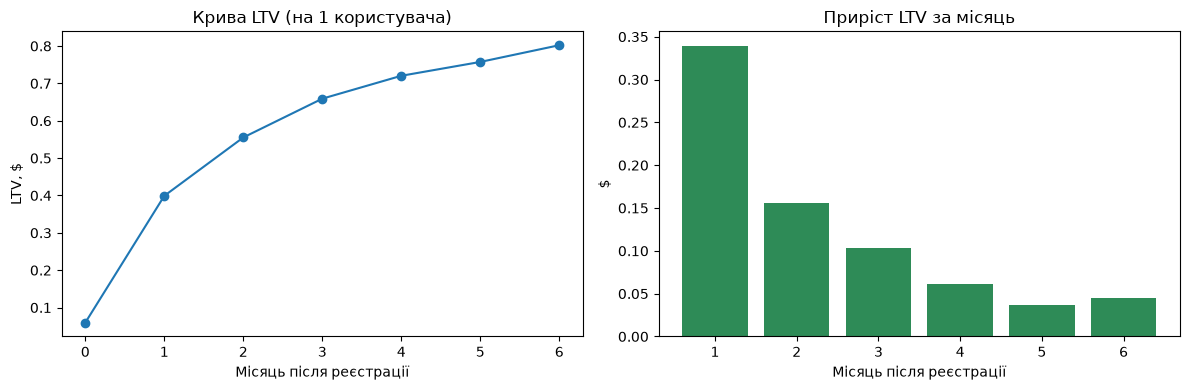

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Крива LTV (накопичувальна)
axes[0].plot(ltv.index, ltv['ltv'], marker='o')
axes[0].set_title('Крива LTV (на 1 користувача)')
axes[0].set_xlabel('Місяць після реєстрації')
axes[0].set_ylabel('LTV, $')

# Скільки додає кожен місяць
axes[1].bar(ltv.index[1:], ltv['increase'][1:], color='seagreen')
axes[1].set_title('Приріст LTV за місяць')
axes[1].set_xlabel('Місяць після реєстрації')
axes[1].set_ylabel('$')

plt.tight_layout()
plt.show()

# 5. Висновки

- **LTV 6-го місяця ≈ $0.80 на 1 зареєстрованого користувача.**
- Платниками стають лише ≈ 6% користувачів, а в середньому платник приносить ≈ $13.8 за 6 місяців.
- Крива росте найшвидше в перший місяць (це приблизно половина LTV6), далі приріст сповільнюється.
- Крива після 6-го місяця ще не плоска: додаткові оплати надходять і далі, тому LTV6 — це не повний LTV за весь час.

**Важливі припущення й обмеження:**
1. Вважаємо, що `revenue_usd` — це дохід за одну оплату (а не накопичена сума). Це варто уточнити в замовника.
2. Місяць рахуємо як календарний місяць від дати реєстрації.
3. Платників небагато (≈ 200), тому цифри можуть помітно коливатися. Місячні прирости теж не ідеально плавні.
4. Це середнє за всіх користувачів. Різні періоди реєстрації можуть давати різний LTV.